In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [2]:
def visualize(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            
            print(cluster_centers)
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                for a in algorithms:
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().cummin().to_frame().reset_index()
                        print(s_min)
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=axes[0]
                        print(axes[0])

                        # Plot the line plot on the first axis

                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1],cmap="YlGnBu", fmt=".3f",norm=mcolors.LogNorm())
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0],cmap='YlGnBu')

                        
                        # Adjust layout
                        plt.tight_layout()
                        if save:
                            file_name=f'{problem}_{a}_run_{run}.pdf'
                            plt.savefig('figures_clustering_new/{file_name}',bbox_inches=0)
                        # Show the combined plot
                        plt.show()
                        
                        '''plt.figure()
                        sns.lineplot(s,x='iteration',y='scaled_raw_y', hue='cluster',palette='tab10')
                        plt.show()
                        
                        plt.figure(figsize=(5,dimension*2))
                        sns.heatmap(df.loc[a,run].T,annot=True)
                        plt.show()'''

In [3]:
def visualize_multi(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False, popsize=50):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            print(cluster_centers)
            cluster_count=cluster_centers.shape[0]
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                fig, all_axes = plt.subplots(len(algorithms), 2 if plot_y else 1, figsize=(cluster_count if plot_y else 10, 3*dimension * len(algorithms)), squeeze=False, sharex=True)
                for a_index, a in enumerate(algorithms):
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().to_frame().reset_index()
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        #fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=all_axes[a_index]

                        # Plot the line plot on the first axis
                        axes[0].set_title(f'Algorithm: {a}; Run: {run}')
                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1], vmin=0, vmax=1)
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0], vmin=0, vmax=popsize,cmap='YlGnBu')

                        
                        # Adjust layout
                
                plt.tight_layout()
                plt.margins(0, tight=True)
                if save:
                    file_name=f"{data_dir.split('/')[-1]}_{problem}_{'+'.join(algorithms)}_run_{'+'.join([str(r) for r in runs])}.pdf"
                    plt.savefig(f'figures_clustering_new/{file_name}',bbox_inches='tight', pad_inches=0)
                # Show the combined plot
                plt.show()

    scaled_x0  scaled_x1
0   -4.506071   0.739825
1    4.704962   1.113329
2    1.679289  -2.346696
3    0.842224   4.836045
4    1.986328   1.357429
5    4.199785   3.411639
6   -4.353082  -2.935249
7   -2.485013   4.056321
8   -0.486453  -2.543323
9   -0.513161  -0.700279
10   6.920552   6.920552
11   4.394972  -4.052919
12   1.693545   3.227716
13  -2.058065   0.477612
14  -1.662091   2.328483
15  -2.363569  -1.646984
16   2.621036  -4.485051
17   1.733504  -0.708778
18  -3.823823   2.362890
19   3.390271   2.365381
20   4.816365   4.866271
21   4.136451  -1.986477
22   0.252033  -4.438771
23  -4.748201   4.650353
24  -0.636479   4.692898
25   3.687380  -0.218881
26  -4.436954  -1.152565
27   0.187710   2.858599
28   0.292468   0.715075
29  -2.053311  -4.204542
30   2.739178   4.703101
31  -4.454171  -4.678587
{0: '-4.51, 0.74', 1: '4.7, 1.11', 2: '1.68, -2.35', 3: '0.84, 4.84', 4: '1.99, 1.36', 5: '4.2, 3.41', 6: '-4.35, -2.94', 7: '-2.49, 4.06', 8: '-0.49, -2.54', 9: '-0.51, -0.7'

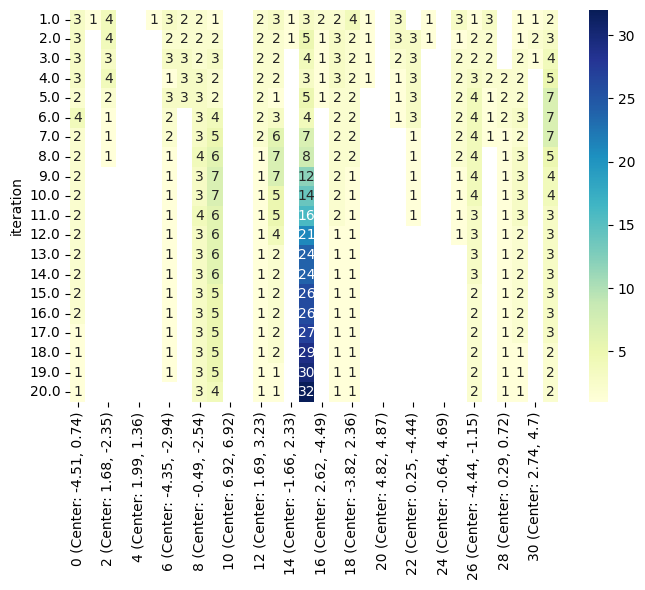

F23_I1 IGWO 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.095766
1          1.0        1      0.095766
2          1.0        3      0.095766
3          1.0        4      0.095766
4          1.0        5      0.095766
..         ...      ...           ...
341       20.0       19      0.021486
342       20.0       24      0.021486
343       20.0       25      0.021486
344       20.0       27      0.021486
345       20.0       28      0.021486

[346 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


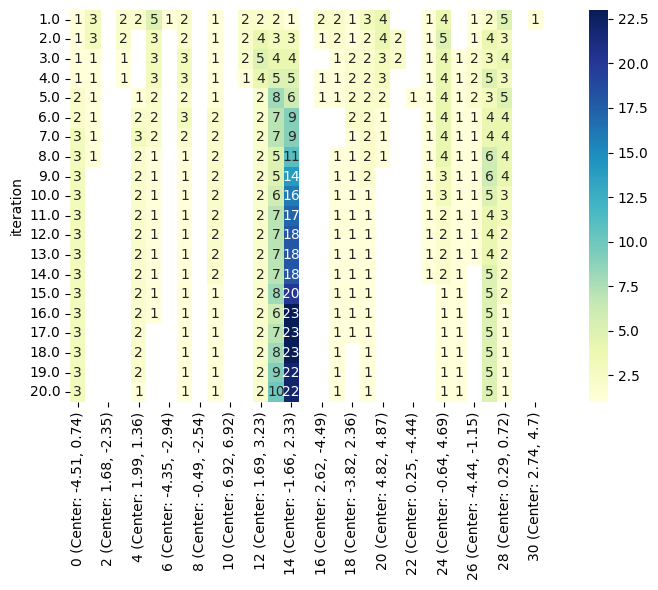

F23_I1 RW_GWO 1
     iteration  cluster  scaled_raw_y
0          1.0        0      0.031955
1          1.0        1      0.031955
2          1.0        2      0.031955
3          1.0        3      0.031955
4          1.0        4      0.031955
..         ...      ...           ...
171       16.0        0      0.027600
172       17.0        0      0.027600
173       18.0        0      0.027600
174       19.0        0      0.027600
175       20.0        0      0.027600

[176 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


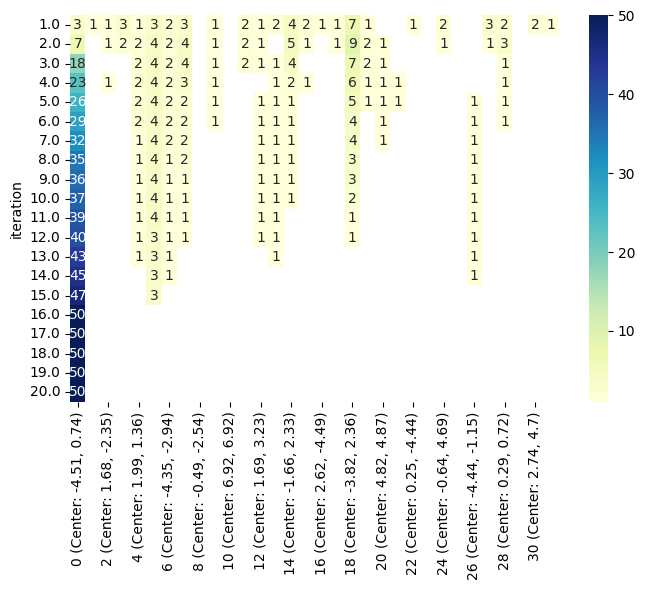

F23_I1 RW_GWO 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.225546
1          1.0        1      0.225546
2          1.0        2      0.225546
3          1.0        3      0.225546
4          1.0        4      0.198942
..         ...      ...           ...
210       19.0        4      0.002966
211       19.0       12      0.002966
212       19.0       17      0.002966
213       19.0       28      0.002966
214       20.0       17      0.002966

[215 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


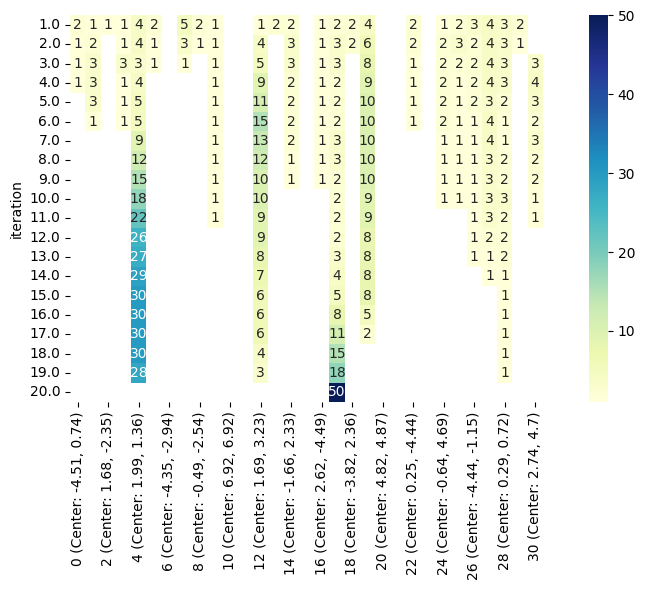

In [5]:
visualize([2], ['F23_I1'], ['IGWO', 'RW_GWO'], [1,2], data_dir=f'data/clustering_features_20_algorithms_kmeans', plot_y=False)

    scaled_x0  scaled_x1
0   -1.373253   4.742902
1   -2.276693   2.352879
2    1.913864   1.871038
3   -4.974601   4.066603
4   -2.698203   3.120298
..        ...        ...
59  -0.394126   2.179747
60  -3.853850   3.587391
61  -4.289668  -2.396733
62  -1.533390   2.625525
63   2.779470  -3.984201

[64 rows x 2 columns]
{0: '-1.37, 4.74', 1: '-2.28, 2.35', 2: '1.91, 1.87', 3: '-4.97, 4.07', 4: '-2.7, 3.12', 5: '0.35, 0.31', 6: '-3.28, 3.52', 7: '4.56, -0.67', 8: '-1.1, 2.01', 9: '-2.75, 1.35', 10: '6.9, 6.9', 11: '-3.34, 2.76', 12: '1.15, -3.24', 13: '2.89, 2.84', 14: '-4.03, 2.66', 15: '-3.85, -0.22', 16: '1.38, 1.38', 17: '-1.64, 0.91', 18: '-1.5, 1.74', 19: '-4.93, 4.87', 20: '-0.03, 4.72', 21: '2.88, 0.1', 22: '-2.18, 3.11', 23: '-4.14, 4.95', 24: '-2.87, 3.89', 25: '-4.22, 3.41', 26: '-3.05, 3.0', 27: '0.98, 0.99', 28: '0.09, 3.39', 29: '4.49, -2.34', 30: '-4.9, 3.19', 31: '-2.3, -3.12', 32: '-3.49, 3.78', 33: '4.44, 4.39', 34: '-1.97, 2.53', 35: '-0.86, 1.33', 36: '-1.21, -0.79'

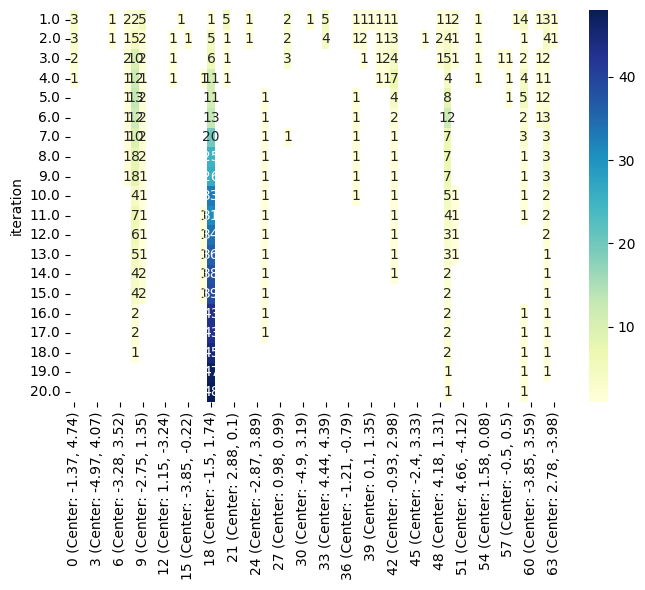

F15_I1 OriginalWOA 5
     iteration  cluster  scaled_raw_y
0          1.0        0      0.008733
1          1.0        1      0.005514
2          1.0        7      0.005514
3          1.0        8      0.001656
4          1.0        9      0.001656
..         ...      ...           ...
176       19.0       18      0.000691
177       19.0       45      0.000691
178       20.0        8      0.000691
179       20.0       18      0.000686
180       20.0       45      0.000686

[181 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


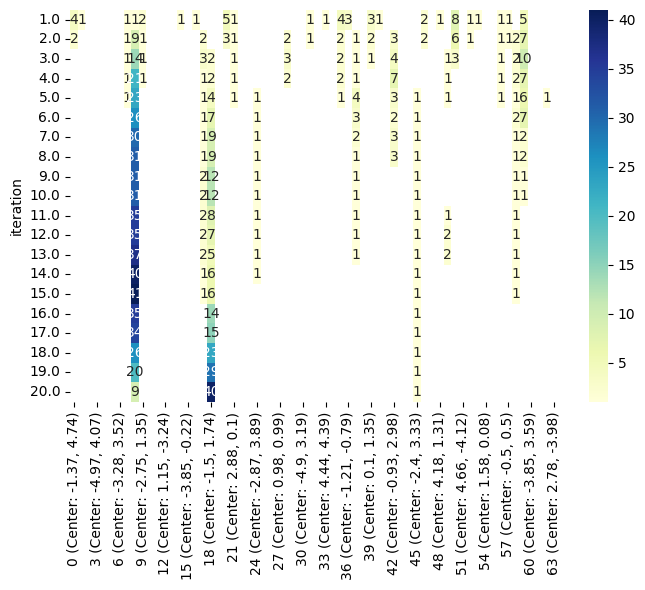

F15_I1 OriginalMRFO 1
     iteration  cluster  scaled_raw_y
0          1.0        0      0.009163
1          1.0        3      0.000840
2          1.0        9      0.000840
3          1.0       14      0.000633
4          1.0       15      0.000633
..         ...      ...           ...
294       20.0       34      0.000157
295       20.0       37      0.000157
296       20.0       43      0.000157
297       20.0       58      0.000157
298       20.0       60      0.000157

[299 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


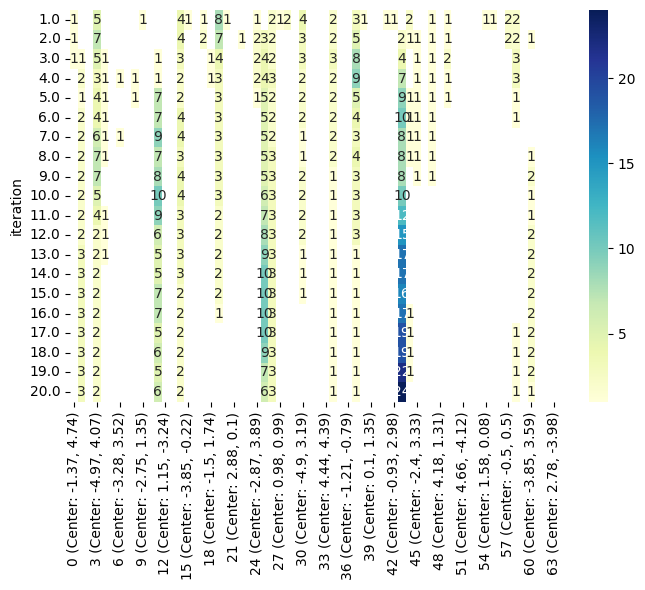

F15_I1 OriginalMRFO 5
     iteration  cluster  scaled_raw_y
0          1.0        0  1.086700e-02
1          1.0        1  2.395818e-03
2          1.0        2  2.395818e-03
3          1.0        3  1.177221e-03
4          1.0        6  1.177221e-03
..         ...      ...           ...
346       20.0       37  1.628239e-09
347       20.0       43  1.628239e-09
348       20.0       44  1.628239e-09
349       20.0       45  1.628239e-09
350       20.0       60  1.628239e-09

[351 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


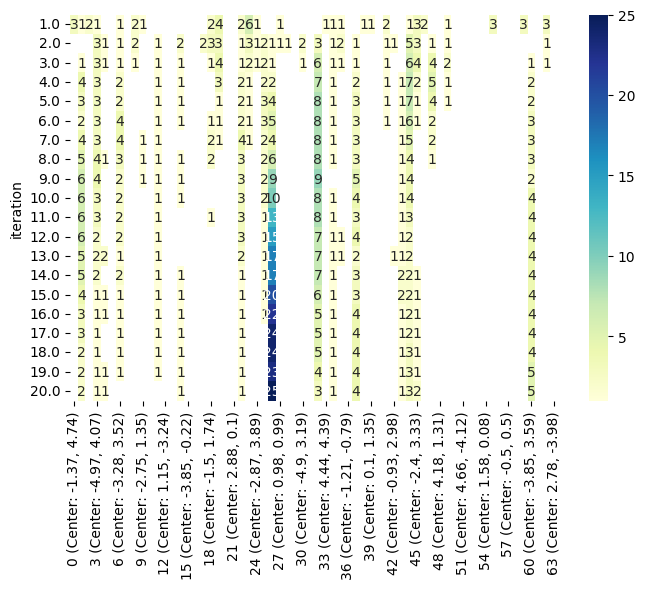

In [8]:
algorithms_of_interest=["ModifiedAEO",
"OriginalAEO",
"AugmentedAEO",
"OriginalSHADE",
"SADE",
"JADE",
"OriginalDE",
"OriginalWOA",
"HI_WOA"]

visualize([2], ['F15_I1'], ['OriginalWOA', 'OriginalMRFO'], [1, 5],data_dir=f'data/clustering_features_20_algorithms_kmeans', plot_y=False)

    scaled_x0  scaled_x1
0    0.696035   3.028912
1   -3.714131  -4.177999
2   -3.751480   0.669291
3    3.160058   0.191228
4   -0.372920  -1.294787
5    3.934715   3.916903
6    1.267934  -3.799207
7   -0.152386   1.873247
8   -4.933009  -4.931390
9   -2.819148  -2.127691
10  -2.181630   1.168811
11   1.317995   1.227807
12   3.090869   3.126785
13  -4.904522   0.315171
14  -2.013404   4.325558
15  -3.079907   0.901111
16  -4.694434  -4.474640
17  -1.277539   1.454729
18   3.228135  -4.090158
19   5.901539   5.901539
20   4.186086   0.476357
21   1.852593  -0.379086
22  -0.434427   3.034645
23   4.153603   1.987876
24  -4.430019  -1.575454
25   0.123741   0.395397
26   2.149999   2.282634
27   0.269566   4.452823
28   4.885571   0.704651
29  -1.583197  -1.632593
30  -2.334186  -0.433736
31  -4.241407   0.519143
{0: '0.7, 3.03', 1: '-3.71, -4.18', 2: '-3.75, 0.67', 3: '3.16, 0.19', 4: '-0.37, -1.29', 5: '3.93, 3.92', 6: '1.27, -3.8', 7: '-0.15, 1.87', 8: '-4.93, -4.93', 9: '-2.82, -2.

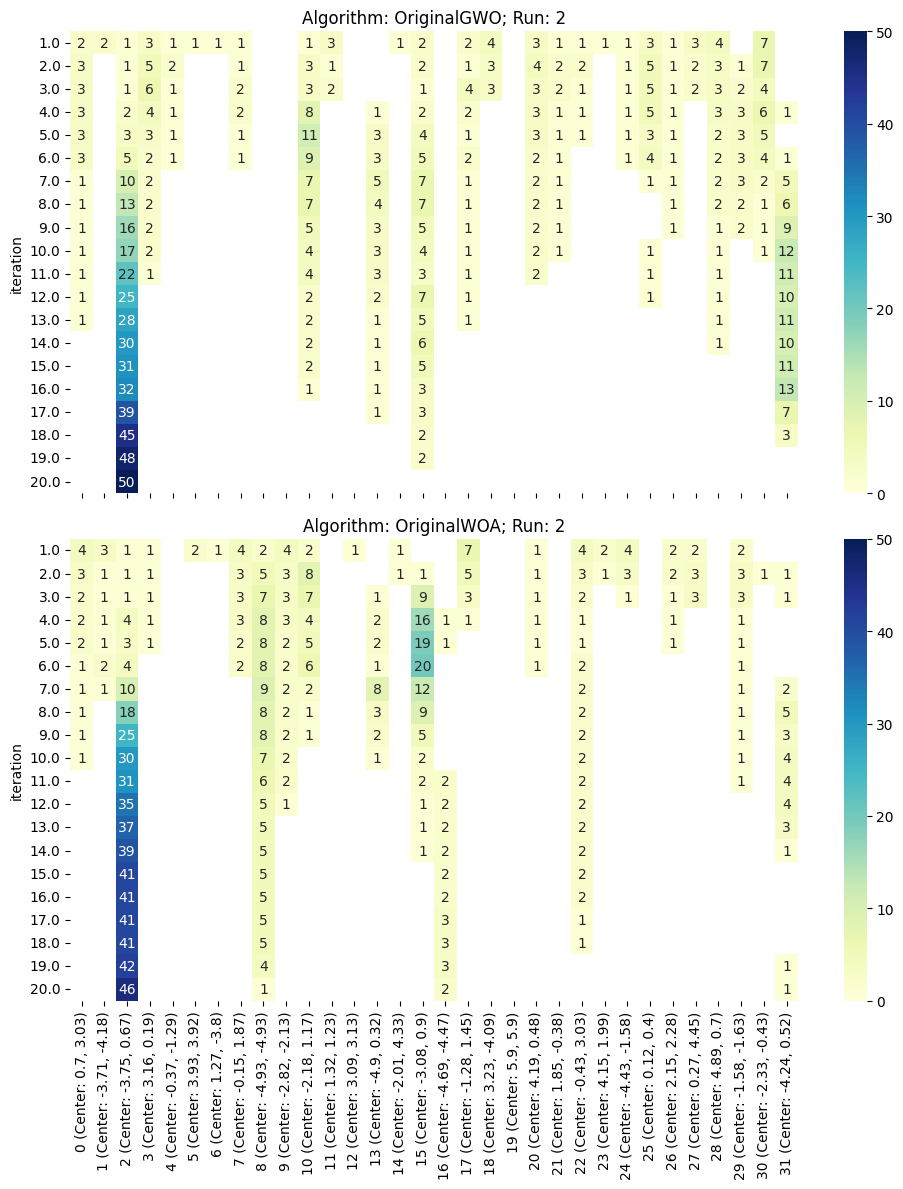

In [9]:
visualize_multi([2], ['F22_I4'], ['OriginalGWO', 'OriginalWOA'], [2], data_dir=f'data/clustering_features_20_algorithms_kmeans', save=False)

    scaled_x0  scaled_x1
0   -3.972148  -1.234860
1    1.357306   0.687638
2    2.222401  -1.474899
3   -2.202401  -3.930452
4    4.963233   4.816738
5    0.149812   2.968521
6    3.750254  -4.466731
7    1.330552  -3.826856
8    0.671117   2.091277
9   -1.433744  -2.404713
10   1.940562  -0.686159
11  -3.212254   1.359382
12   3.687309   4.658015
13   4.381537  -1.883849
14  -3.169579  -4.638957
15   2.556319  -2.226117
16  -0.523267   4.459360
17  -4.464407   3.544253
18  -4.821566   0.245106
19  -3.319215  -2.911953
20   5.905573   5.905573
21  -1.736743  -1.238511
22   1.109047   1.205875
23   1.653432   0.012463
24   2.945099  -3.165357
25  -1.149484  -3.601711
26  -0.149956  -4.603826
27  -2.038946  -4.673320
28   1.683675   1.680145
29   1.716672   3.817835
30   3.436395   3.094946
31  -2.254296  -0.066921
{0: '-3.97, -1.23', 1: '1.36, 0.69', 2: '2.22, -1.47', 3: '-2.2, -3.93', 4: '4.96, 4.82', 5: '0.15, 2.97', 6: '3.75, -4.47', 7: '1.33, -3.83', 8: '0.67, 2.09', 9: '-1.43, -2.4

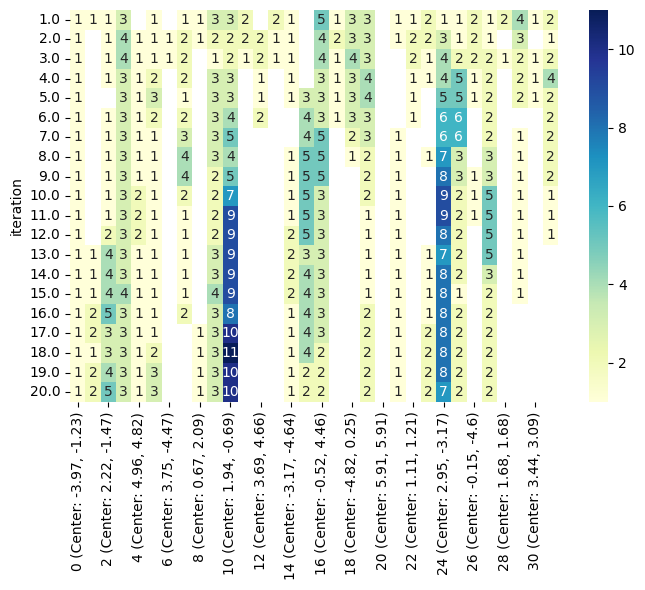

F22_I1 SADE 1
     iteration  cluster  scaled_raw_y
0          1.0        0  1.573270e-01
1          1.0        2  2.737402e-02
2          1.0        3  2.427832e-02
3          1.0        5  5.894500e-03
4          1.0        6  5.894500e-03
..         ...      ...           ...
374       20.0       15  7.846215e-08
375       20.0       22  7.846215e-08
376       20.0       23  7.846215e-08
377       20.0       24  7.846215e-08
378       20.0       27  7.846215e-08

[379 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


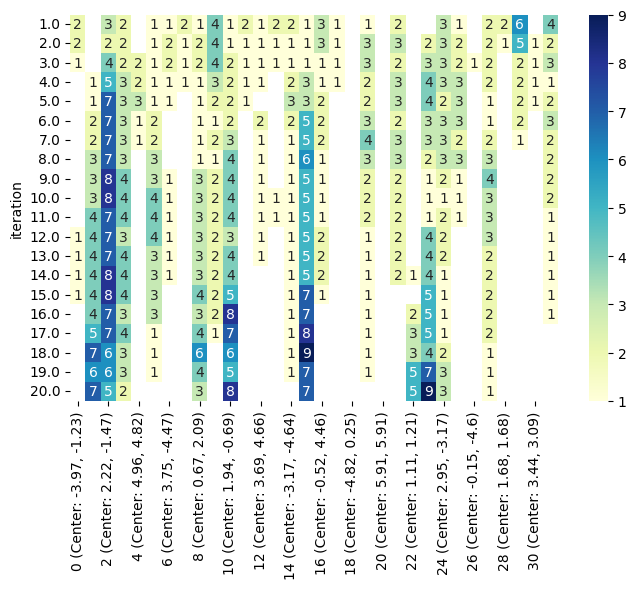

F22_I1 OriginalDE 1
     iteration  cluster  scaled_raw_y
0          1.0        2      0.109312
1          1.0        3      0.023474
2          1.0        5      0.023474
3          1.0        6      0.023474
4          1.0        7      0.023474
..         ...      ...           ...
139       18.0        8      0.000189
140       18.0       22      0.000017
141       19.0        8      0.000017
142       19.0       22      0.000017
143       20.0       22      0.000016

[144 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


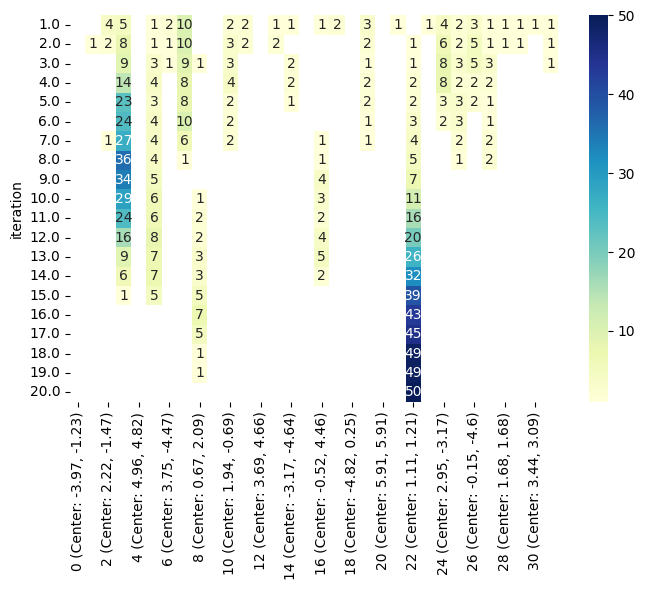

F22_I1 OriginalSHADE 1
     iteration  cluster  scaled_raw_y
0          1.0        0  1.563844e-01
1          1.0        2  1.558373e-02
2          1.0        4  1.558373e-02
3          1.0        5  1.558373e-02
4          1.0        6  1.558373e-02
..         ...      ...           ...
355       20.0       21  8.881784e-15
356       20.0       23  8.881784e-15
357       20.0       24  8.881784e-15
358       20.0       25  8.881784e-15
359       20.0       27  8.881784e-15

[360 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


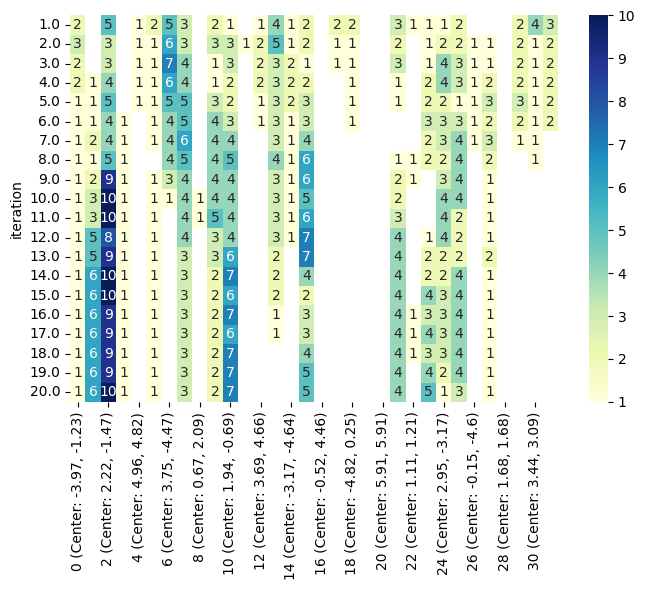

In [10]:
visualize([2], ['F22_I1'], ['JADE','SADE', 'OriginalDE', 'OriginalSHADE'], [1],data_dir=f'data/clustering_features_20_algorithms_kmeans', plot_y=False)

               x0        x1
cluster                    
0        1.729852 -0.107014
1       -2.108146 -4.064414
2        3.137685 -2.926323
3        3.013816 -2.712674
4        2.076122 -1.567749
5        0.342436  2.794042
6        0.196607  3.127413
7       -0.776240  4.990246
8       -0.468697  4.420479
9        3.695253  4.979582
10       1.372527 -3.863461
11       1.786065 -3.709730
{0: '1.73, -0.11', 1: '-2.11, -4.06', 2: '3.14, -2.93', 3: '3.01, -2.71', 4: '2.08, -1.57', 5: '0.34, 2.79', 6: '0.2, 3.13', 7: '-0.78, 4.99', 8: '-0.47, 4.42', 9: '3.7, 4.98', 10: '1.37, -3.86', 11: '1.79, -3.71'}
F22_I1 JADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0      0.000695
1         1.0        1      0.000695
2         1.0       12      0.000695
3         2.0        0      0.000695
4         2.0        1      0.000695
..        ...      ...           ...
67       19.0        1      0.000028
68       19.0       12      0.000028
69       20.0        0      0.000028
70       

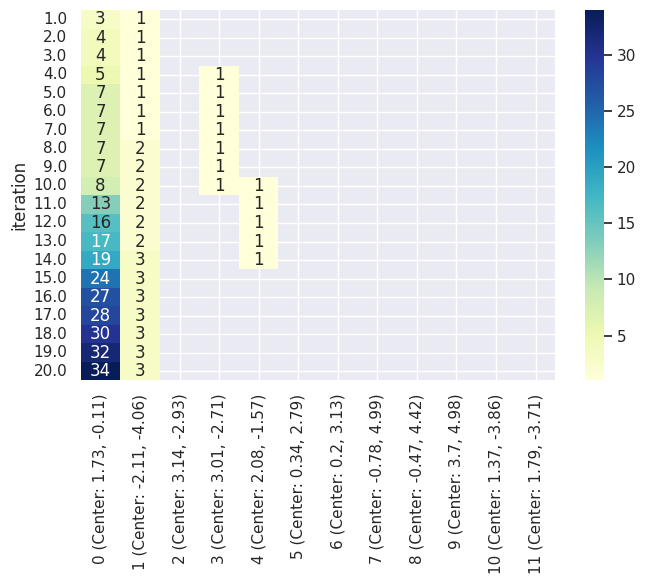

F22_I1 JADE 2
    iteration  cluster  scaled_raw_y
0         1.0        0  1.448633e-04
1         1.0       12  1.448633e-04
2         2.0        0  1.448633e-04
3         2.0       12  1.448633e-04
4         3.0        0  3.646967e-05
5         3.0       12  3.646967e-05
6         4.0        0  3.646967e-05
7         4.0       12  3.646967e-05
8         5.0        0  3.646967e-05
9         5.0        4  3.646967e-05
10        5.0       12  3.646967e-05
11        6.0        0  2.936462e-07
12        6.0        4  2.936462e-07
13        6.0       12  2.936462e-07
14        7.0        0  2.936462e-07
15        7.0        4  2.936462e-07
16        7.0       12  2.936462e-07
17        8.0        0  2.936462e-07
18        8.0        4  2.936462e-07
19        8.0       12  2.936462e-07
20        9.0        0  2.936462e-07
21        9.0        4  2.936462e-07
22        9.0       12  2.936462e-07
23       10.0        0  2.936462e-07
24       10.0        4  2.936462e-07
25       10.0       12  

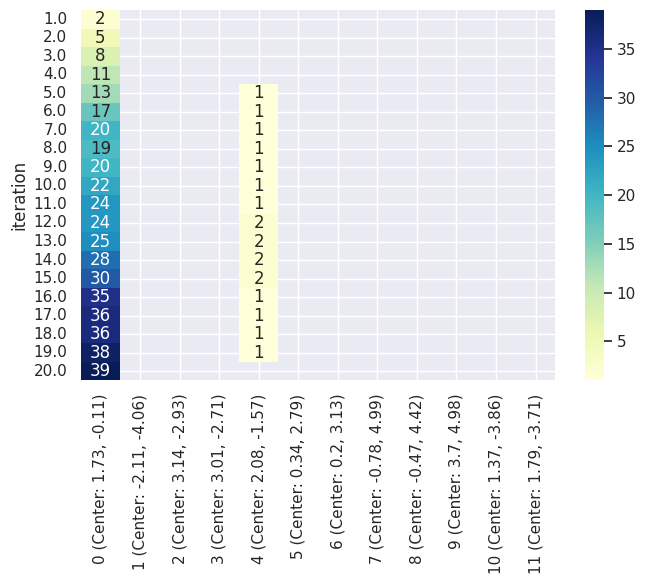

F22_I1 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0       12  1.664504e-02
1          2.0        0  1.664504e-02
2          2.0       12  1.664504e-02
3          3.0        0  9.735603e-04
4          3.0       12  9.735603e-04
..         ...      ...           ...
96        20.0        4  5.226475e-07
97        20.0        6  5.226475e-07
98        20.0        8  5.226475e-07
99        20.0       11  5.226475e-07
100       20.0       12  5.226475e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


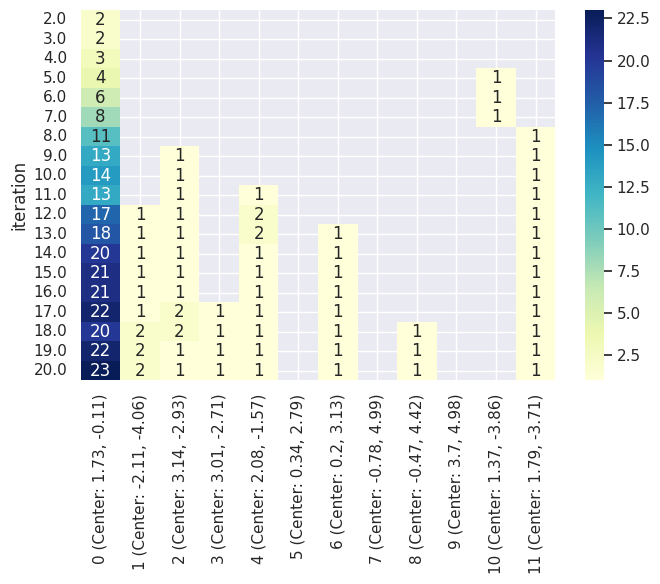

F22_I1 SADE 1
    iteration  cluster  scaled_raw_y
0         1.0        0  5.562651e-03
1         1.0        1  5.562651e-03
2         1.0       12  5.562651e-03
3         2.0        0  5.562651e-03
4         2.0        5  5.562651e-03
..        ...      ...           ...
75       19.0       12  8.971728e-07
76       20.0        0  8.971728e-07
77       20.0        4  8.971728e-07
78       20.0        7  8.971728e-07
79       20.0       12  8.971728e-07

[80 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


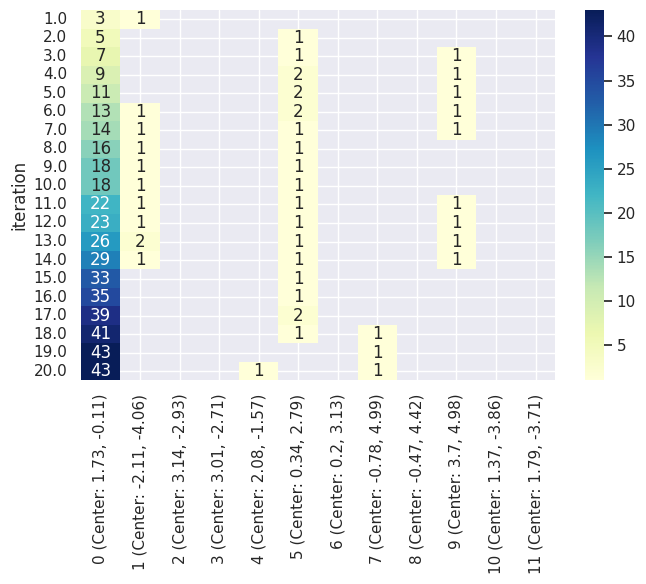

F22_I1 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0      0.005585
1          1.0        5      0.005157
2          1.0       12      0.005157
3          2.0        0      0.001835
4          2.0        5      0.001835
..         ...      ...           ...
97        19.0       12      0.000001
98        20.0        0      0.000001
99        20.0        1      0.000001
100       20.0        2      0.000001
101       20.0       12      0.000001

[102 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


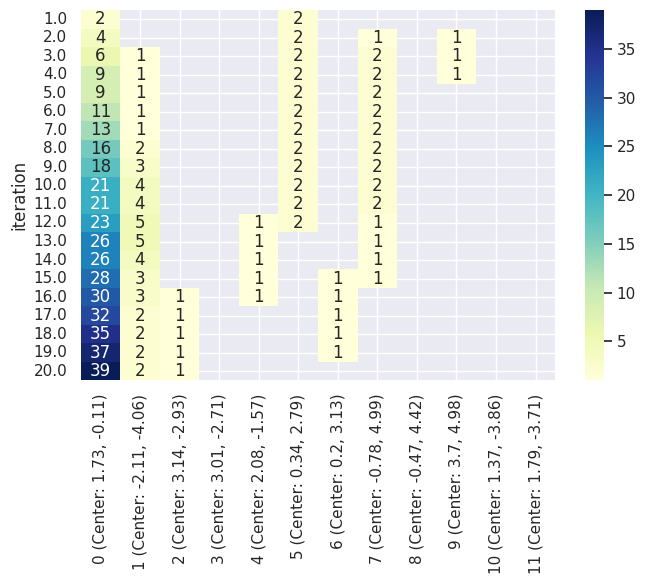

F22_I1 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  1.147716e-02
1          1.0        1  1.147716e-02
2          1.0       12  1.147716e-02
3          2.0        0  1.902050e-06
4          2.0        5  1.902050e-06
..         ...      ...           ...
96        20.0        1  5.236849e-07
97        20.0        5  5.236849e-07
98        20.0        6  5.236849e-07
99        20.0        8  5.236849e-07
100       20.0       12  5.236849e-07

[101 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


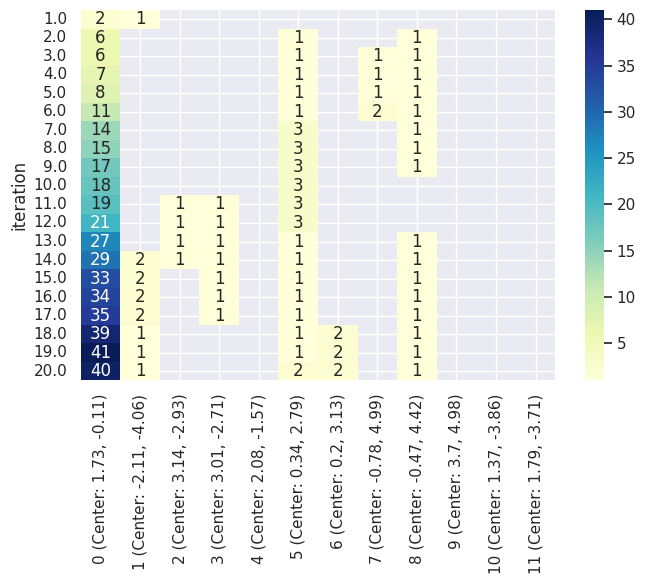

In [ ]:
visualize([2], ['F22_I1'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_10_algorithms_dbscan', plot_y=False)

In [11]:
dimension=2
directory=f'data/clustering_features_20_algorithms_kmeans/cluster_distributions/dim_{dimension}'

trajectory_similarities=[]
for file in tqdm(os.listdir(directory)):
    file_loc=f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df=pd.read_csv(file_loc,index_col=[0,1,2])
        d_algorithm_run=df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
        trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]

trajectory_similarities=pd.concat(trajectory_similarities)
t=trajectory_similarities.groupby('algorithm').count()['run']
t_max=t.max()
algorithms_to_remove=list(t[t<t_max].index)
trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

100%|██████████| 120/120 [00:02<00:00, 51.08it/s]


In [12]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
5499,WhaleFOA,5,OriginalHHO,5,0.000000,F18_I3,18,3
9886,RW_GWO,2,WhaleFOA,4,0.000000,F6_I3,6,3
195,WhaleFOA,1,AugmentedAEO,2,0.000000,F1_I3,1,3
196,WhaleFOA,2,AugmentedAEO,2,0.000000,F1_I3,1,3
197,WhaleFOA,3,AugmentedAEO,2,0.000000,F1_I3,1,3
...,...,...,...,...,...,...,...,...
3202,AugmentedAEO,3,OriginalAEO,3,0.999457,F5_I3,5,3
6602,AugmentedAEO,3,OriginalMRFO,2,0.999498,F5_I4,5,4
266,OriginalMRFO,2,AugmentedAEO,3,0.999498,F5_I4,5,4
6904,AugmentedAEO,5,OriginalMRFO,5,0.999540,F5_I2,5,2


100%|██████████| 120/120 [00:02<00:00, 40.07it/s]


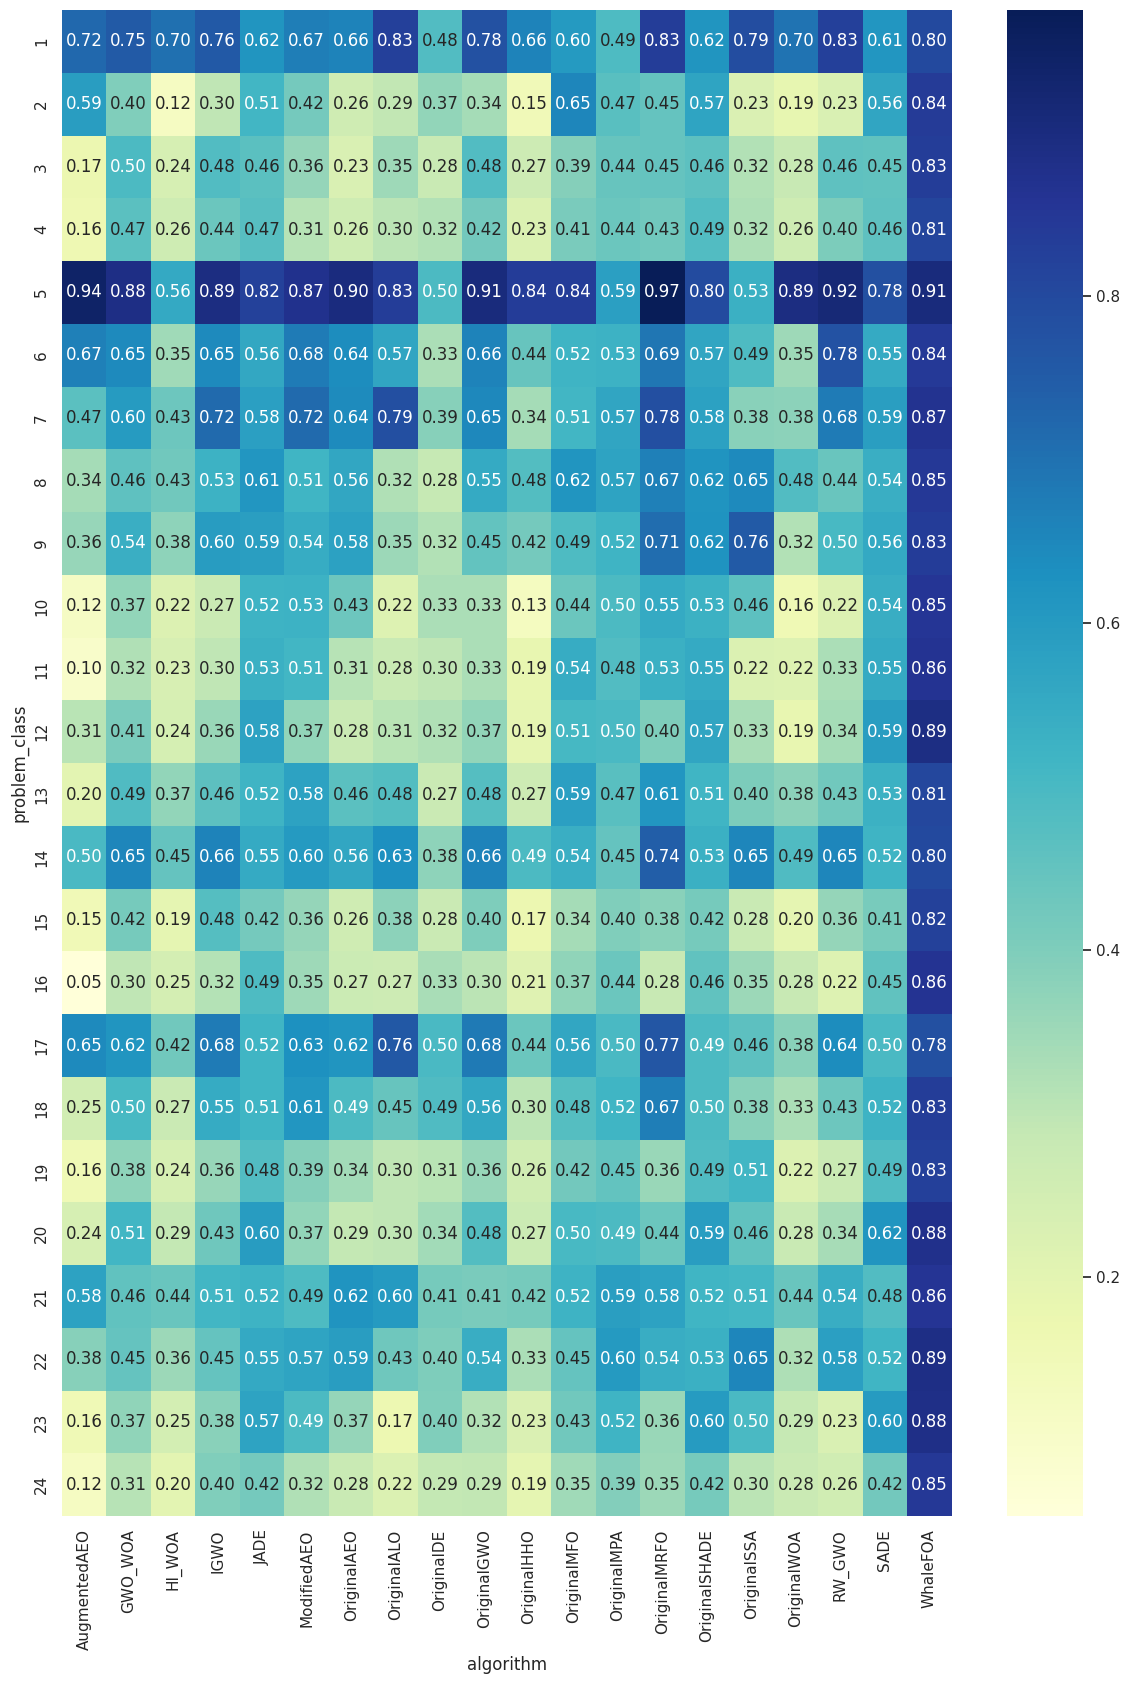

<Figure size 1500x1500 with 0 Axes>

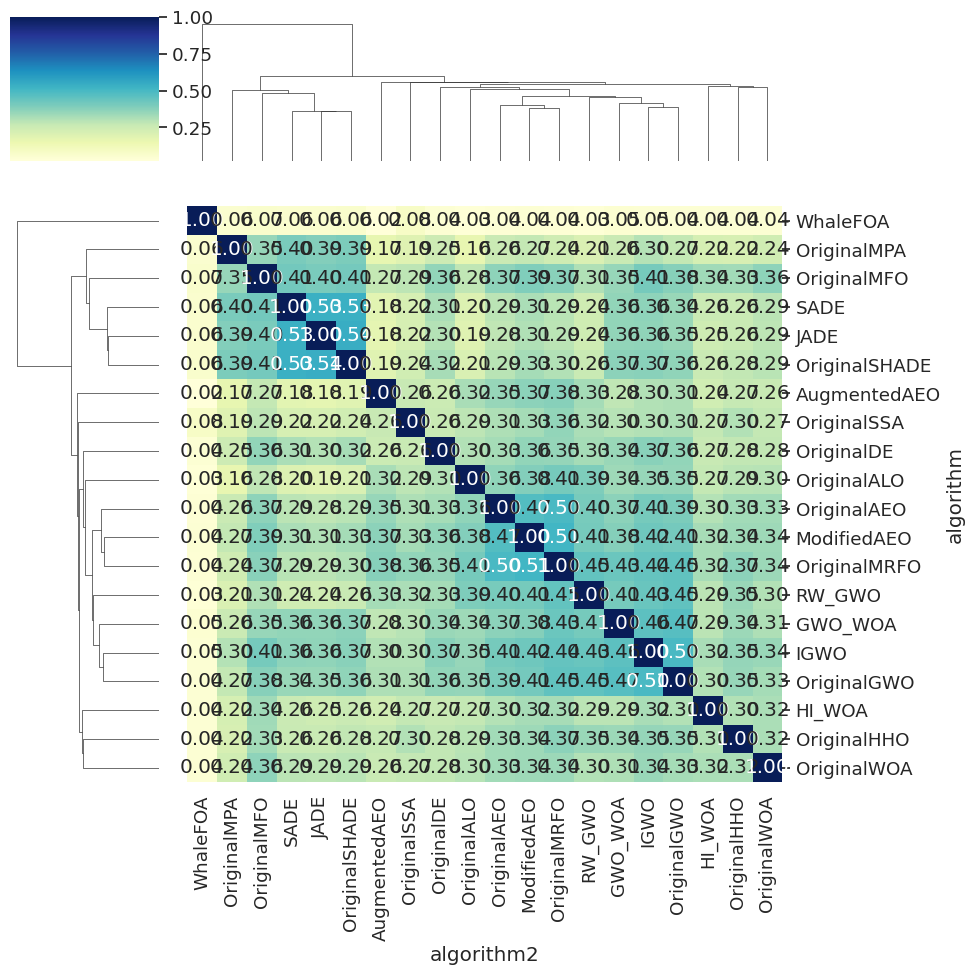

In [15]:
for dimension in [2]:
    directory=f'data/clustering_features_20_algorithms_kmeans/cluster_distributions/dim_{dimension}'
    scale=False
    trajectory_similarities=[]
    for file in tqdm(os.listdir(directory)):
        file_loc=f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df=pd.read_csv(file_loc,index_col=[0,1,2])
            d_algorithm_run=df.unstack(level=-1).dropna()
            d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
            trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]
    
    trajectory_similarities=pd.concat(trajectory_similarities)
    t=trajectory_similarities.groupby('algorithm').count()['run']
    t_max=t.max()
    algorithms_to_remove=list(t[t<t_max].index)
    trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['run'] = trajectory_similarities['run'].astype(int)
    trajectory_similarities['run2'] = trajectory_similarities['run2'].astype(int)

    plt.figure(figsize=(12,17))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf')

    cross_algorithm_similarity=trajectory_similarities.query('run==run2').groupby(['algorithm','algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted=cross_algorithm_similarity.reset_index().pivot(index='algorithm',columns='algorithm2',values='value')
    sns.set_theme(font_scale=1.2)
    plt.figure(figsize=(15,15))
    sns.clustermap(cross_algorithm_similarity_pivoted,annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new_dbscan/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf')
    sns.set_theme(font_scale=1)


In [16]:
optimizer_group=get_algorithm_groups()


In [17]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'data/clustering_features_10_algorithms_dbscan/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [18]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

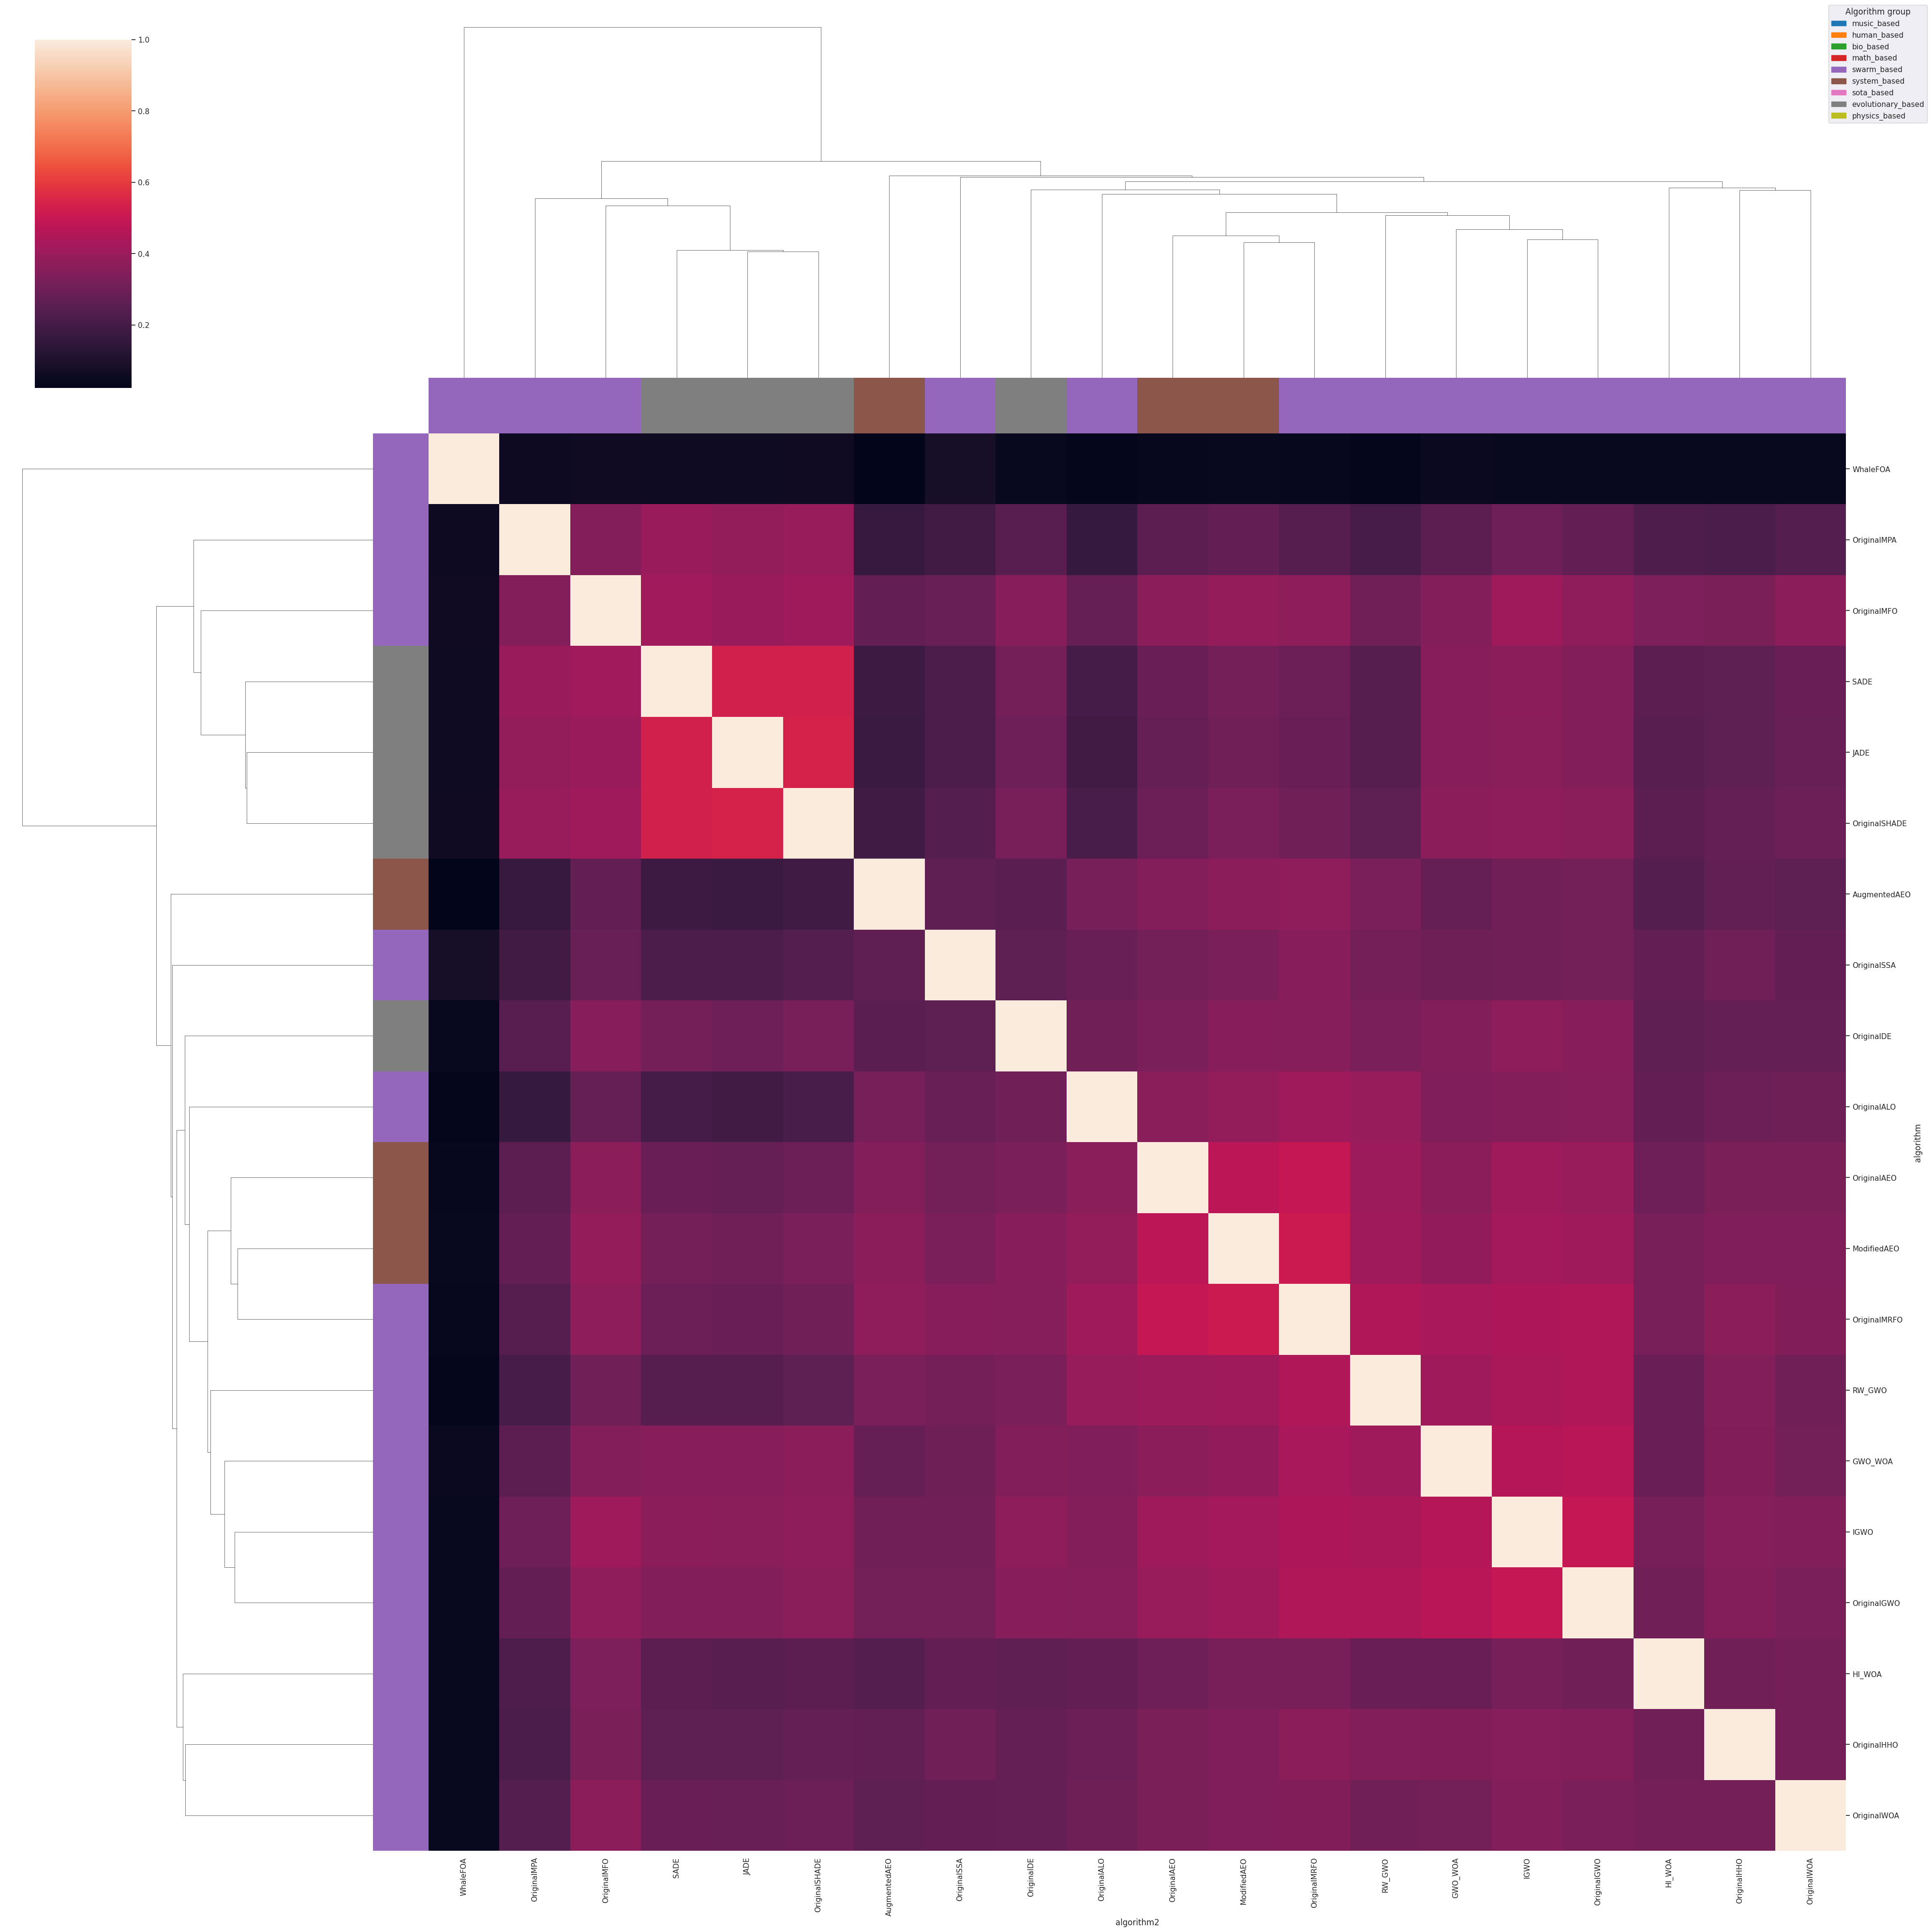

In [19]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering_dbscan/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
#plt.show()
